# Assignment 4

## Task 1: Basis Functions and their Support

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [4]:
x = np.linspace(-3, 3, 500)
mu_vals = [-2, -1, 0, 1, 2]
s = 0.5


phi_linear_0 = np.ones_like(x)
phi_linear_1 = x

def polynomial_basis(x, j):
    return x**j

def gaussian_basis(x, mu, s):
    return np.exp(-((x - mu)**2) / (2 * s**2))

def sigmoid_basis(x, mu, s):
    return 1 / (1 + np.exp(-(x - mu) / s))



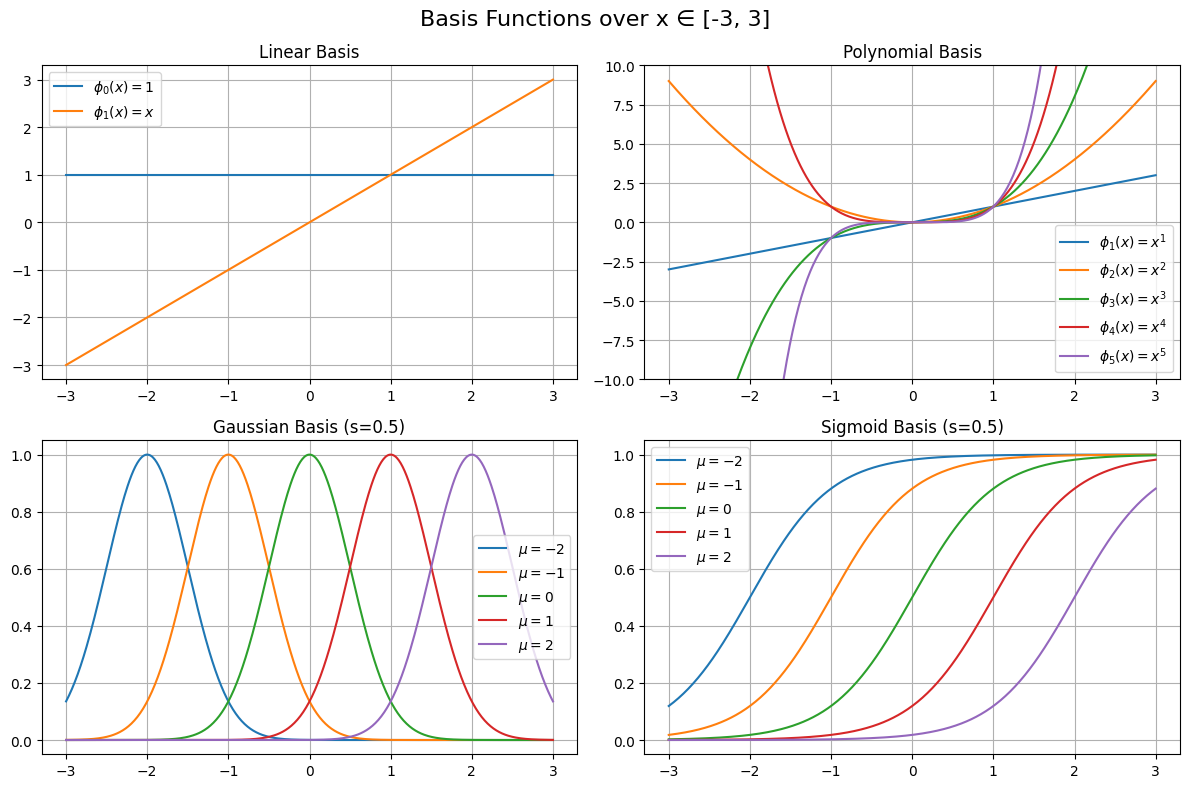

In [5]:
# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Basis Functions over x ∈ [-3, 3]', fontsize=16)

# Plot Linear
axes[0, 0].plot(x, phi_linear_0, label=r'$\phi_0(x) = 1$')
axes[0, 0].plot(x, phi_linear_1, label=r'$\phi_1(x) = x$')
axes[0, 0].set_title('Linear Basis')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot Polynomial (Fixed f-string with raw prefix and double braces for LaTeX)
for j in range(1, 6):
    axes[0, 1].plot(x, polynomial_basis(x, j), label=rf'$\phi_{{{j}}}(x) = x^{{{j}}}$')
axes[0, 1].set_title('Polynomial Basis')
axes[0, 1].set_ylim(-10, 10)
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot Gaussian (Fixed f-string with raw prefix)
for mu in mu_vals:
    axes[1, 0].plot(x, gaussian_basis(x, mu, s), label=rf'$\mu={mu}$')
axes[1, 0].set_title(f'Gaussian Basis (s={s})')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot Sigmoid (Fixed f-string with raw prefix)
for mu in mu_vals:
    axes[1, 1].plot(x, sigmoid_basis(x, mu, s), label=rf'$\mu={mu}$')
axes[1, 1].set_title(f'Sigmoid Basis (s={s})')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [6]:
x0 = 0.3
delta = 0.1
x1 = x0 + delta
print("Polynomial Basis: |phi_j(0.4) - phi_j(0.3)|")
print(f"{'j':<5} | {'phi(0.3)':<10} | {'phi(0.4)':<10} | {'|Diff|':<10}")
print("-" * 45)
for j in range(1, 6):
    val0 = polynomial_basis(x0, j)
    val1 = polynomial_basis(x1, j)
    diff = abs(val1 - val0)
    print(f"{j:<5} | {val0:<10.5f} | {val1:<10.5f} | {diff:<10.5f}")

print("\n")

# 2. Gaussian Basis Evaluation
print("Gaussian Basis: |phi_j(0.4) - phi_j(0.3)|")
print(f"{'mu':<5} | {'phi(0.3)':<10} | {'phi(0.4)':<10} | {'|Diff|':<10}")
print("-" * 45)
for mu in mu_vals:
    val0 = gaussian_basis(x0, mu, s)
    val1 = gaussian_basis(x1, mu, s)
    diff = abs(val1 - val0)
    print(f"{mu:<5} | {val0:<10.5f} | {val1:<10.5f} | {diff:<10.5f}")

print("\n")

# 3. Sigmoid Basis Evaluation
print("Sigmoid Basis: |phi_j(0.4) - phi_j(0.3)|")
print(f"{'mu':<5} | {'phi(0.3)':<10} | {'phi(0.4)':<10} | {'|Diff|':<10}")
print("-" * 45)
for mu in mu_vals:
    val0 = sigmoid_basis(x0, mu, s)
    val1 = sigmoid_basis(x1, mu, s)
    diff = abs(val1 - val0)
    print(f"{mu:<5} | {val0:<10.5f} | {val1:<10.5f} | {diff:<10.5f}")

Polynomial Basis: |phi_j(0.4) - phi_j(0.3)|
j     | phi(0.3)   | phi(0.4)   | |Diff|    
---------------------------------------------
1     | 0.30000    | 0.40000    | 0.10000   
2     | 0.09000    | 0.16000    | 0.07000   
3     | 0.02700    | 0.06400    | 0.03700   
4     | 0.00810    | 0.02560    | 0.01750   
5     | 0.00243    | 0.01024    | 0.00781   


Gaussian Basis: |phi_j(0.4) - phi_j(0.3)|
mu    | phi(0.3)   | phi(0.4)   | |Diff|    
---------------------------------------------
-2    | 0.00003    | 0.00001    | 0.00002   
-1    | 0.03405    | 0.01984    | 0.01421   
0     | 0.83527    | 0.72615    | 0.10912   
1     | 0.37531    | 0.48675    | 0.11144   
2     | 0.00309    | 0.00598    | 0.00289   


Sigmoid Basis: |phi_j(0.4) - phi_j(0.3)|
mu    | phi(0.3)   | phi(0.4)   | |Diff|    
---------------------------------------------
-2    | 0.99005    | 0.99184    | 0.00179   
-1    | 0.93086    | 0.94268    | 0.01181   
0     | 0.64566    | 0.68997    | 0.04432   
1     | 0.1

##Task 2: Polynomial Basis for a Smooth Global Trend


In [7]:
# 1. Generate Data
np.random.seed(42) # Ensures we get the same random numbers every time
n = 150

# Generate 150 samples uniformly between -2 and 2
X = np.random.uniform(-2, 2, n).reshape(-1, 1)

# Generate Gaussian noise with mean 0 and standard deviation 0.2
epsilon = np.random.normal(0, 0.2, n).reshape(-1, 1)

# Calculate the target variable y
y = 1 + 0.8 * X - 1.5 * X**2 + 0.5 * X**3 + epsilon

In [8]:
# First split: 60% Train, 40% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Second split: Divide the 40% Temp into 20% Validation and 20% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [9]:
degrees = [1, 2, 3, 5,8,150,200]
mse_results = {}
models = {}

X_plot = np.linspace(-2.2, 2.2, 150).reshape(-1, 1)
predictions_for_plot = {}

In [10]:
def create_polynomial_features(X, degree):
    """
    Transforms a 1D array of features into a polynomial design matrix.
    Adds a column of 1s for the bias term (degree 0).
    """
    n_samples = X.shape[0]
    # Start with a column of ones for the bias/intercept
    X_poly = np.ones((n_samples, 1))

    # Horizontally stack X^1, X^2, ..., X^degree
    for d in range(1, degree + 1):
        X_poly = np.hstack((X_poly, X**d))

    return X_poly

def fit_linear_regression(X, y):
    """
    Calculates weights using the Normal Equation: theta = (X^T * X)^(-1) * X^T * y
    We use np.linalg.pinv (pseudoinverse) for better numerical stability.
    """
    theta = np.linalg.pinv(X.T @ X) @ X.T @ y
    return theta

def predict(X, theta):
    """Generates predictions via dot product of features and weights."""
    return X @ theta

def calculate_mse(y_true, y_pred):
    """Calculates Mean Squared Error."""
    return np.mean((y_true - y_pred)**2)

In [11]:
for degree in degrees:
    # 1. Create polynomial features manually
    X_train_poly = create_polynomial_features(X_train, degree)
    X_val_poly = create_polynomial_features(X_val, degree)
    X_test_poly = create_polynomial_features(X_test, degree)
    X_plot_poly = create_polynomial_features(X_plot, degree)

    # 2. Fit the model (calculate theta weights)
    theta = fit_linear_regression(X_train_poly, y_train)

    # 3. Predict and calculate MSE
    train_pred = predict(X_train_poly, theta)
    val_pred = predict(X_val_poly, theta)
    test_pred = predict(X_test_poly, theta)

    train_mse = calculate_mse(y_train, train_pred)
    val_mse = calculate_mse(y_val, val_pred)
    test_mse = calculate_mse(y_test, test_pred)

    # Store results
    mse_results[degree] = {'Train': train_mse, 'Val': val_mse, 'Test': test_mse}

    # Store predictions for the plotting step
    predictions_for_plot[degree] = predict(X_plot_poly, theta)

# Print the MSE table
print(f"{'Degree':<10} | {'Train MSE':<12} | {'Val MSE':<12} | {'Test MSE':<12}")
print("-" * 55)
for deg, mses in mse_results.items():
    print(f"{deg:<10} | {mses['Train']:<12.4f} | {mses['Val']:<12.4f} | {mses['Test']:<12.4f}")

Degree     | Train MSE    | Val MSE      | Test MSE    
-------------------------------------------------------
1          | 3.7034       | 4.5798       | 3.2932      
2          | 0.4063       | 0.3996       | 0.4515      
3          | 0.0437       | 0.0352       | 0.0498      
5          | 0.0419       | 0.0358       | 0.0482      
8          | 0.0398       | 0.0374       | 0.0381      
150        | 7.1418       | 152871.4749  | 329407.0831 
200        | 7.9837       | 47418.2842   | 2013650.9266


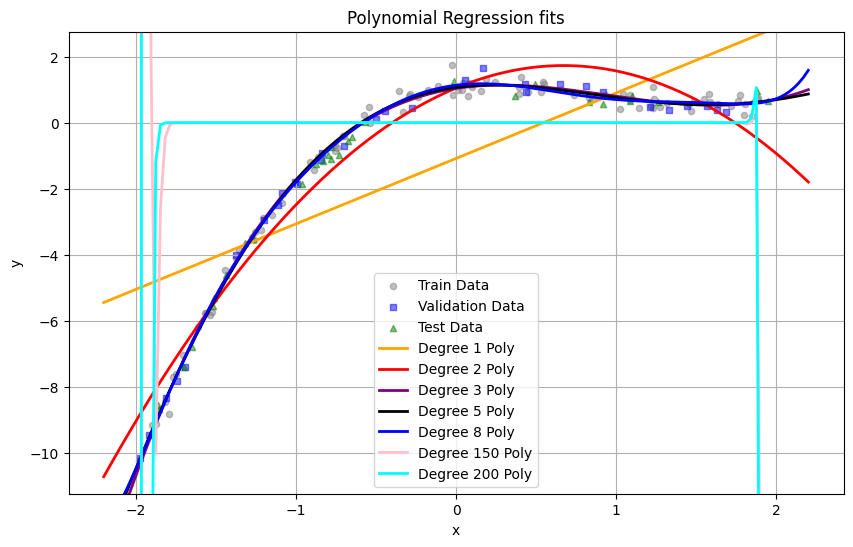

In [12]:
plt.figure(figsize=(10, 6))

# Plot the split datasets
plt.scatter(X_train, y_train, color='gray', alpha=0.5, label='Train Data', s=20)
plt.scatter(X_val, y_val, color='blue', alpha=0.5, label='Validation Data', s=20, marker='s')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data', s=20, marker='^')

# Define colors for our 4 polynomial lines
colors = {1: 'orange', 2: 'red', 3: 'purple', 5: 'black',8:"blue",150:"pink",200:"cyan"}

# Plot each fitted model
for degree in degrees:
    plt.plot(X_plot, predictions_for_plot[degree], color=colors[degree],
             label=f'Degree {degree} Poly', linewidth=2)

plt.title('Polynomial Regression fits')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.ylim(y.min() - 1, y.max() + 1) # Keep y-axis boundaries clean
plt.show()

### Analysis of Polynomial Basis Functions

* **Effect of Increasing Polynomial Degree:**
  * **Underfitting (Low Degrees, $d = 1, 2$):** Degree 1 (linear) and Degree 2 (quadratic) exhibit high bias; they are too rigid to capture the true underlying curvature, missing the sharp transition in the negative region and plateauing behavior near $x > 0$.
  * **Optimal Balance (Moderate Degrees, $d = 3, 5$):** Degrees 3 and 5 provide the best generalizable fit. They accurately trace the steep drop for $x < -0.5$ and conform to the flattened, slightly oscillatory pattern for $x > 0$ without fitting random noise.
  * **Mild Overfitting (Degree $d = 8$):** As the degree reaches 8, the curve begins to show artificial turning and slight oscillation at the boundaries (e.g., kicking upward sharply near $x \approx 2.0$), illustrating the early onset of boundary instability.
  * **Extreme Overfitting & Numerical Instability (Very High Degrees, $d = 150, 200$):** Very high degrees suffer severely from Runge's phenomenon and ill-conditioned normal equations. The fitted functions collapse to a flat, uninformative horizontal line across the center and oscillate wildly toward infinity near the boundaries ($x \approx -1.9$ and $x \approx 1.9$).

* **Why Polynomial Basis Functions Are Suitable for a Smooth Global Trend:**
  * **Infinite Differentiability ($C^\infty$ Smoothness):** Polynomials $\phi_j(x) = x^j$ are infinitely smooth everywhere, naturally producing continuous and gentle transitions across the input domain without artificial kinks or sharp breakpoints.
  * **Global Support:** Because each monomial basis term spans the entire real line rather than a compact local window, a small change in coefficients creates a coherent, domain-wide adjustment—ideal for capturing overarching trajectories, monotonic saturation, or slow-varying curvature.
  * **Parsimony for Simple Trends:** Low-to-moderate degree polynomials approximate smooth, slowly drifting targets with very few parameters, avoiding the need to manually choose hyperparameter centers or bandwidths required by localized kernels.

##Task 3: Local and Transition-based Regression

In [13]:
np.random.seed(42)

In [14]:
def fit_linear_regression(Phi_train, y_train):
    """
    Fit theta using the normal equation: theta = pinv(Phi^T Phi) Phi^T y
    Phi_train : design matrix of shape (n_samples, n_features)
    y_train   : target vector of shape (n_samples,)
    returns   : theta, shape (n_features,)
    """
    theta = np.linalg.pinv(Phi_train.T @ Phi_train) @ Phi_train.T @ y_train
    return theta


def predict(Phi, theta):
    """Simple prediction: Phi @ theta"""
    return Phi @ theta


def mse(y_true, y_pred):
    """Mean Squared Error"""
    return np.mean((y_true - y_pred) ** 2)


In [15]:
def build_linear_basis(x):
    """phi_0 = 1, phi_1 = x"""
    Phi = np.column_stack([np.ones_like(x), x])
    return Phi


def build_polynomial_basis(x, degree):
    """phi_0 = 1, phi_1 = x, phi_2 = x^2, ... phi_degree = x^degree"""
    columns = [np.ones_like(x)]
    for j in range(1, degree + 1):
        columns.append(x ** j)
    Phi = np.column_stack(columns)
    return Phi


def build_gaussian_basis(x, centers, s):
    """phi_0 = 1, then one Gaussian bump per center"""
    columns = [np.ones_like(x)]
    for mu in centers:
        col = np.exp(-((x - mu) ** 2) / (2 * s ** 2))
        columns.append(col)
    Phi = np.column_stack(columns)
    return Phi


def build_sigmoid_basis(x, centers, s):
    """phi_0 = 1, then one sigmoid step per center"""
    columns = [np.ones_like(x)]
    for mu in centers:
        col = 1.0 / (1.0 + np.exp(-(x - mu) / s))
        columns.append(col)
    Phi = np.column_stack(columns)
    return Phi

In [16]:
def train_val_test_split(x, y, train_frac=0.6, val_frac=0.2, seed=0):
    n = len(x)
    rng = np.random.RandomState(seed)
    indices = np.arange(n)
    rng.shuffle(indices)

    n_train = int(train_frac * n)
    n_val = int(val_frac * n)

    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train + n_val]
    test_idx = indices[n_train + n_val:]

    x_train, y_train = x[train_idx], y[train_idx]
    x_val, y_val = x[val_idx], y[val_idx]
    x_test, y_test = x[test_idx], y[test_idx]

    return x_train, y_train, x_val, y_val, x_test, y_test

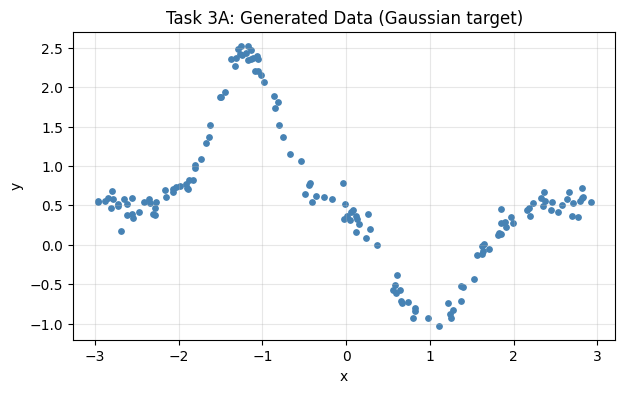

In [17]:
n = 150
x_3a = np.random.uniform(-3, 3, n)

true_y_3a = (0.5
             + 2 * np.exp(-((x_3a + 1.2) ** 2) / (2 * 0.35 ** 2))
             - 1.5 * np.exp(-((x_3a - 1.0) ** 2) / (2 * 0.45 ** 2)))

noise_3a = np.random.normal(0, 0.1, n)
y_3a = true_y_3a + noise_3a

plt.figure(figsize=(7, 4))
plt.scatter(x_3a, y_3a, s=15, color="steelblue")
plt.title("Task 3A: Generated Data (Gaussian target)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()

In [18]:
x_train_3a, y_train_3a, x_val_3a, y_val_3a, x_test_3a, y_test_3a = \
    train_val_test_split(x_3a, y_3a, train_frac=0.6, val_frac=0.2, seed=1)

print("Train size:", len(x_train_3a))
print("Val size  :", len(x_val_3a))
print("Test size :", len(x_test_3a))


Train size: 90
Val size  : 30
Test size : 30


In [19]:
centers_3a = np.linspace(-3, 3, 9)
s_values_3a = [0.25, 0.5, 1.0]

gaussian_results_3a = {}   # s -> dict with theta, train/val/test mse

for s in s_values_3a:
    Phi_train = build_gaussian_basis(x_train_3a, centers_3a, s)
    Phi_val = build_gaussian_basis(x_val_3a, centers_3a, s)
    Phi_test = build_gaussian_basis(x_test_3a, centers_3a, s)

    theta = fit_linear_regression(Phi_train, y_train_3a)

    train_mse = mse(y_train_3a, predict(Phi_train, theta))
    val_mse = mse(y_val_3a, predict(Phi_val, theta))
    test_mse = mse(y_test_3a, predict(Phi_test, theta))

    gaussian_results_3a[s] = {
        "theta": theta,
        "train_mse": train_mse,
        "val_mse": val_mse,
        "test_mse": test_mse,
    }

    print(f"s = {s:>4} | Train MSE = {train_mse:.4f} | Val MSE = {val_mse:.4f} | Test MSE = {test_mse:.4f}")

s = 0.25 | Train MSE = 0.1157 | Val MSE = 0.1452 | Test MSE = 0.1298
s =  0.5 | Train MSE = 0.0422 | Val MSE = 0.0565 | Test MSE = 0.0383
s =  1.0 | Train MSE = 0.0426 | Val MSE = 0.0537 | Test MSE = 0.0389


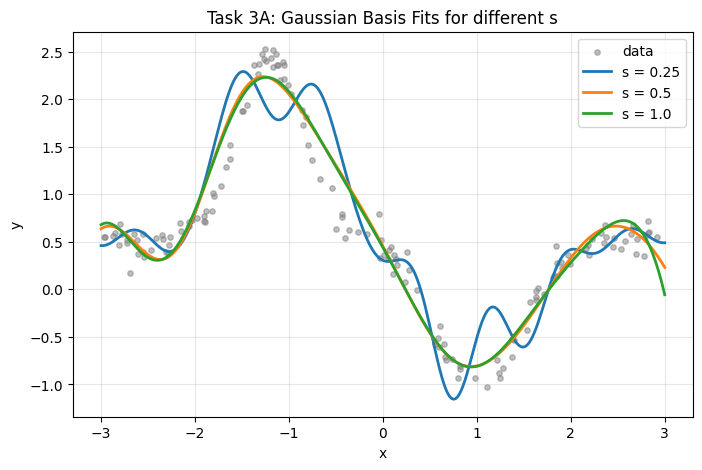

In [20]:
# Plot the fitted curves for every s value, together with the data
x_plot_3a = np.linspace(-3, 3, 300)

plt.figure(figsize=(8, 5))
plt.scatter(x_3a, y_3a, s=15, color="gray", alpha=0.5, label="data")

for s in s_values_3a:
    Phi_plot = build_gaussian_basis(x_plot_3a, centers_3a, s)
    y_plot = predict(Phi_plot, gaussian_results_3a[s]["theta"])
    plt.plot(x_plot_3a, y_plot, linewidth=2, label=f"s = {s}")

plt.title("Task 3A: Gaussian Basis Fits for different s")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [21]:
best_s_3a = min(s_values_3a, key=lambda s: gaussian_results_3a[s]["val_mse"])
print("Best s (chosen using Validation MSE):", best_s_3a)
print("Its Test MSE:", gaussian_results_3a[best_s_3a]["test_mse"])


Best s (chosen using Validation MSE): 1.0
Its Test MSE: 0.03891516120360113


- With a very small `s` (0.25), each Gaussian bump is very narrow, so the model
  can only "see" a small neighbourhood around each center. Adjacent centers
  barely overlap, so the fit tends to be wiggly with small gaps of low
  confidence between centers -> in our run this gave clearly the **worst**
  Train/Val/Test MSE of the three settings.
- As `s` increases (0.5 and then 1.0), the bumps around the 9 centers start to
  overlap more, letting the model combine several basis functions smoothly to
  build the two required bumps (one positive near $x=-1.2$, one negative near
  $x=1.0$). Both `s = 0.5` and `s = 1.0` performed clearly better than `s = 0.25`,
  and in our run the code above picked `s = 1.0` as the best (lowest Validation
  MSE), with `s = 0.5` a very close second — showing that once `s` is "large
  enough" relative to the 9-center spacing, performance becomes fairly flat.
- If `s` were pushed much larger than what we tried, the bumps would eventually
  overlap so much that the Gaussian basis would lose its local character and
  start **underfitting** sharp, localized structure.
- Gaussian basis functions are suitable here because they are **local** — each
  basis function only has a strong response near its own center `mu_j` and decays
  to (almost) zero far away. This matches the structure of the target function,
  which is a sum of two localized bumps, not a smooth global trend.


## Part B: Sigmoid Basis

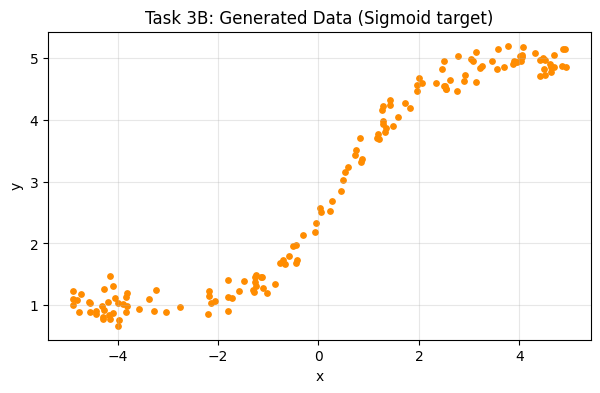

In [22]:
n = 150
x_3b = np.random.uniform(-5, 5, n)

true_y_3b = 1 + 4 * (1.0 / (1.0 + np.exp(-(x_3b - 0.5) / 0.8)))
noise_3b = np.random.normal(0, 0.15, n)
y_3b = true_y_3b + noise_3b

plt.figure(figsize=(7, 4))
plt.scatter(x_3b, y_3b, s=15, color="darkorange")
plt.title("Task 3B: Generated Data (Sigmoid target)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()

In [23]:
x_train_3b, y_train_3b, x_val_3b, y_val_3b, x_test_3b, y_test_3b = \
    train_val_test_split(x_3b, y_3b, train_frac=0.6, val_frac=0.2, seed=2)

print("Train size:", len(x_train_3b))
print("Val size  :", len(x_val_3b))
print("Test size :", len(x_test_3b))

Train size: 90
Val size  : 30
Test size : 30


In [24]:
centers_3b = np.array([-2, -1, 0, 1, 2])
s_values_3b = [0.3, 0.8, 1.5]

sigmoid_results_3b = {}

for s in s_values_3b:
    Phi_train = build_sigmoid_basis(x_train_3b, centers_3b, s)
    Phi_val = build_sigmoid_basis(x_val_3b, centers_3b, s)
    Phi_test = build_sigmoid_basis(x_test_3b, centers_3b, s)

    theta = fit_linear_regression(Phi_train, y_train_3b)

    train_mse = mse(y_train_3b, predict(Phi_train, theta))
    val_mse = mse(y_val_3b, predict(Phi_val, theta))
    test_mse = mse(y_test_3b, predict(Phi_test, theta))

    sigmoid_results_3b[s] = {
        "theta": theta,
        "train_mse": train_mse,
        "val_mse": val_mse,
        "test_mse": test_mse,
    }

    print(f"s = {s:>4} | Train MSE = {train_mse:.4f} | Val MSE = {val_mse:.4f} | Test MSE = {test_mse:.4f}")


s =  0.3 | Train MSE = 0.0225 | Val MSE = 0.0286 | Test MSE = 0.0309
s =  0.8 | Train MSE = 0.0217 | Val MSE = 0.0272 | Test MSE = 0.0291
s =  1.5 | Train MSE = 0.0226 | Val MSE = 0.0248 | Test MSE = 0.0291


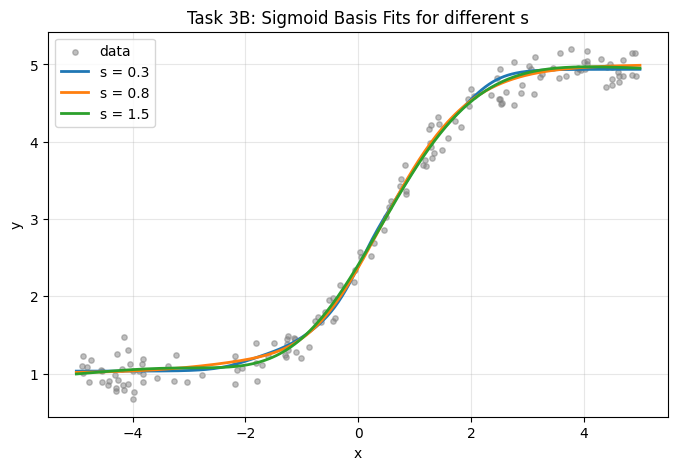

In [25]:
x_plot_3b = np.linspace(-5, 5, 300)

plt.figure(figsize=(8, 5))
plt.scatter(x_3b, y_3b, s=15, color="gray", alpha=0.5, label="data")

for s in s_values_3b:
    Phi_plot = build_sigmoid_basis(x_plot_3b, centers_3b, s)
    y_plot = predict(Phi_plot, sigmoid_results_3b[s]["theta"])
    plt.plot(x_plot_3b, y_plot, linewidth=2, label=f"s = {s}")

plt.title("Task 3B: Sigmoid Basis Fits for different s")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [26]:
best_s_3b = min(s_values_3b, key=lambda s: sigmoid_results_3b[s]["val_mse"])
print("Best s (chosen using Validation MSE):", best_s_3b)
print("Its Test MSE:", sigmoid_results_3b[best_s_3b]["test_mse"])

Best s (chosen using Validation MSE): 1.5
Its Test MSE: 0.029063041583836217


- `s` controls how "sharp" or "smooth" the S-shaped transition of each sigmoid
  basis function is. A **small `s` (0.3)** makes each sigmoid switch from 0 to 1
  very quickly (almost like a step function). In our run this gave the **worst**
  MSE of the three, because with only 5 centers spread over $[-5,5]$, very sharp
  individual steps are harder to blend into one smooth combined transition.
- A **large `s` (1.5)** makes each sigmoid change very gradually, so several of
  them combine into one smooth overall transition curve. In our run `s = 1.5`
  gave the lowest Validation MSE, with `s = 0.8` a close second — both are much
  better than `s = 0.3`.
- This tells us that for a single, fairly broad transition (as we generated
  here), it is better for the individual basis functions to be a bit "wider"
  than the transition itself, so a handful of them can be summed and scaled to
  reproduce the transition smoothly, rather than each one trying to capture the
  whole jump on its own.
- Sigmoid basis functions are suitable for this data because the target itself is
  a **saturating / transition-type** curve: it starts near a low constant value,
  rises through a transition region, and then flattens out near a high constant
  value. This is exactly the shape a sum of sigmoid functions is naturally able
  to represent, unlike Gaussian (which is local and returns to 0) or a
  low-degree polynomial (which cannot saturate/flatten on both sides).

# Task 4: Comparison of Basis Functions

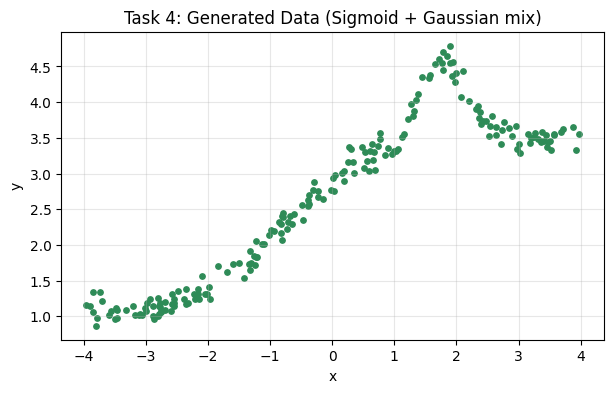

In [27]:
n = 200
x_4 = np.random.uniform(-4, 4, n)

true_y_4 = (1
            + 2.5 * (1.0 / (1.0 + np.exp(-(x_4 + 0.8) / 0.7)))
            + 1.2 * np.exp(-((x_4 - 1.8) ** 2) / (2 * 0.35 ** 2)))

noise_4 = np.random.normal(0, 0.12, n)
y_4 = true_y_4 + noise_4

plt.figure(figsize=(7, 4))
plt.scatter(x_4, y_4, s=15, color="seagreen")
plt.title("Task 4: Generated Data (Sigmoid + Gaussian mix)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()


In [28]:
x_train_4, y_train_4, x_val_4, y_val_4, x_test_4, y_test_4 = \
    train_val_test_split(x_4, y_4, train_frac=0.6, val_frac=0.2, seed=3)

print("Train size:", len(x_train_4))
print("Val size  :", len(x_val_4))
print("Test size :", len(x_test_4))


Train size: 120
Val size  : 40
Test size : 40


In [29]:
all_results_4 = {}

In [30]:
## linear basis

Phi_train = build_linear_basis(x_train_4)
Phi_val = build_linear_basis(x_val_4)
Phi_test = build_linear_basis(x_test_4)

theta = fit_linear_regression(Phi_train, y_train_4)

train_mse = mse(y_train_4, predict(Phi_train, theta))
val_mse = mse(y_val_4, predict(Phi_val, theta))
test_mse = mse(y_test_4, predict(Phi_test, theta))

all_results_4["Linear"] = {
    "theta": theta,
    "param": None,
    "train_mse": train_mse,
    "val_mse": val_mse,
    "test_mse": test_mse,
    "basis_fn": lambda x, th=theta: predict(build_linear_basis(x), th),
}

print(f"Linear | Train MSE = {train_mse:.4f} | Val MSE = {val_mse:.4f} | Test MSE = {test_mse:.4f}")

Linear | Train MSE = 0.2242 | Val MSE = 0.2516 | Test MSE = 0.2344


In [31]:
##polynomial basis for 3 5 7

poly_degrees_4 = [3, 5, 7]
poly_results_4 = {}

for p in poly_degrees_4:
    Phi_train = build_polynomial_basis(x_train_4, p)
    Phi_val = build_polynomial_basis(x_val_4, p)
    Phi_test = build_polynomial_basis(x_test_4, p)

    theta = fit_linear_regression(Phi_train, y_train_4)

    train_mse = mse(y_train_4, predict(Phi_train, theta))
    val_mse = mse(y_val_4, predict(Phi_val, theta))
    test_mse = mse(y_test_4, predict(Phi_test, theta))

    poly_results_4[p] = {"theta": theta, "train_mse": train_mse, "val_mse": val_mse, "test_mse": test_mse}
    print(f"degree = {p} | Train MSE = {train_mse:.4f} | Val MSE = {val_mse:.4f} | Test MSE = {test_mse:.4f}")

best_p_4 = min(poly_degrees_4, key=lambda p: poly_results_4[p]["val_mse"])
print("\nBest polynomial degree (by Validation MSE):", best_p_4)

all_results_4["Polynomial"] = {
    "theta": poly_results_4[best_p_4]["theta"],
    "param": best_p_4,
    "train_mse": poly_results_4[best_p_4]["train_mse"],
    "val_mse": poly_results_4[best_p_4]["val_mse"],
    "test_mse": poly_results_4[best_p_4]["test_mse"],
    "basis_fn": lambda x, th=poly_results_4[best_p_4]["theta"], p=best_p_4: predict(build_polynomial_basis(x, p), th),
}


degree = 3 | Train MSE = 0.0547 | Val MSE = 0.0768 | Test MSE = 0.0538
degree = 5 | Train MSE = 0.0480 | Val MSE = 0.0543 | Test MSE = 0.0485
degree = 7 | Train MSE = 0.0379 | Val MSE = 0.0654 | Test MSE = 0.0283

Best polynomial degree (by Validation MSE): 5


In [32]:
## gausian basis 9 equally spaced centers

centers_4 = np.linspace(-4, 4, 9)
gaussian_s_values_4 = [0.3, 0.6, 1.0]
gaussian_results_4 = {}

for s in gaussian_s_values_4:
    Phi_train = build_gaussian_basis(x_train_4, centers_4, s)
    Phi_val = build_gaussian_basis(x_val_4, centers_4, s)
    Phi_test = build_gaussian_basis(x_test_4, centers_4, s)

    theta = fit_linear_regression(Phi_train, y_train_4)

    train_mse = mse(y_train_4, predict(Phi_train, theta))
    val_mse = mse(y_val_4, predict(Phi_val, theta))
    test_mse = mse(y_test_4, predict(Phi_test, theta))

    gaussian_results_4[s] = {"theta": theta, "train_mse": train_mse, "val_mse": val_mse, "test_mse": test_mse}
    print(f"s = {s} | Train MSE = {train_mse:.4f} | Val MSE = {val_mse:.4f} | Test MSE = {test_mse:.4f}")

best_s_gauss_4 = min(gaussian_s_values_4, key=lambda s: gaussian_results_4[s]["val_mse"])
print("\nBest Gaussian s (by Validation MSE):", best_s_gauss_4)

all_results_4["Gaussian"] = {
    "theta": gaussian_results_4[best_s_gauss_4]["theta"],
    "param": best_s_gauss_4,
    "train_mse": gaussian_results_4[best_s_gauss_4]["train_mse"],
    "val_mse": gaussian_results_4[best_s_gauss_4]["val_mse"],
    "test_mse": gaussian_results_4[best_s_gauss_4]["test_mse"],
    "basis_fn": lambda x, th=gaussian_results_4[best_s_gauss_4]["theta"], s=best_s_gauss_4: predict(build_gaussian_basis(x, centers_4, s), th),
}


s = 0.3 | Train MSE = 0.1025 | Val MSE = 0.1247 | Test MSE = 0.0817
s = 0.6 | Train MSE = 0.0197 | Val MSE = 0.0270 | Test MSE = 0.0155
s = 1.0 | Train MSE = 0.0197 | Val MSE = 0.0248 | Test MSE = 0.0158

Best Gaussian s (by Validation MSE): 1.0


In [33]:
##sigmoid basis

sigmoid_s_values_4 = [0.3, 0.6, 1.0]
sigmoid_results_4 = {}

for s in sigmoid_s_values_4:
    Phi_train = build_sigmoid_basis(x_train_4, centers_4, s)
    Phi_val = build_sigmoid_basis(x_val_4, centers_4, s)
    Phi_test = build_sigmoid_basis(x_test_4, centers_4, s)

    theta = fit_linear_regression(Phi_train, y_train_4)

    train_mse = mse(y_train_4, predict(Phi_train, theta))
    val_mse = mse(y_val_4, predict(Phi_val, theta))
    test_mse = mse(y_test_4, predict(Phi_test, theta))

    sigmoid_results_4[s] = {"theta": theta, "train_mse": train_mse, "val_mse": val_mse, "test_mse": test_mse}
    print(f"s = {s} | Train MSE = {train_mse:.4f} | Val MSE = {val_mse:.4f} | Test MSE = {test_mse:.4f}")

best_s_sig_4 = min(sigmoid_s_values_4, key=lambda s: sigmoid_results_4[s]["val_mse"])
print("\nBest Sigmoid s (by Validation MSE):", best_s_sig_4)

all_results_4["Sigmoid"] = {
    "theta": sigmoid_results_4[best_s_sig_4]["theta"],
    "param": best_s_sig_4,
    "train_mse": sigmoid_results_4[best_s_sig_4]["train_mse"],
    "val_mse": sigmoid_results_4[best_s_sig_4]["val_mse"],
    "test_mse": sigmoid_results_4[best_s_sig_4]["test_mse"],
    "basis_fn": lambda x, th=sigmoid_results_4[best_s_sig_4]["theta"], s=best_s_sig_4: predict(build_sigmoid_basis(x, centers_4, s), th),
}


s = 0.3 | Train MSE = 0.0296 | Val MSE = 0.0315 | Test MSE = 0.0217
s = 0.6 | Train MSE = 0.0266 | Val MSE = 0.0333 | Test MSE = 0.0197
s = 1.0 | Train MSE = 0.0258 | Val MSE = 0.0331 | Test MSE = 0.0189

Best Sigmoid s (by Validation MSE): 0.3


In [34]:
print(f"{'Basis':<12}{'Param':<10}{'Train MSE':<12}{'Val MSE':<12}{'Test MSE':<12}")
print("-" * 58)
for name, res in all_results_4.items():
    param_str = "-" if res["param"] is None else str(res["param"])
    print(f"{name:<12}{param_str:<10}{res['train_mse']:<12.4f}{res['val_mse']:<12.4f}{res['test_mse']:<12.4f}")

Basis       Param     Train MSE   Val MSE     Test MSE    
----------------------------------------------------------
Linear      -         0.2242      0.2516      0.2344      
Polynomial  5         0.0480      0.0543      0.0485      
Gaussian    1.0       0.0197      0.0248      0.0158      
Sigmoid     0.3       0.0296      0.0315      0.0217      


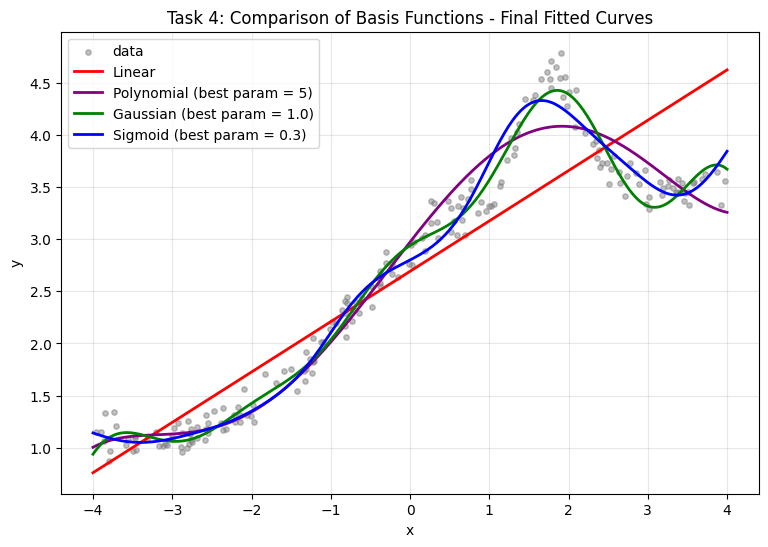

In [35]:
x_plot_4 = np.linspace(-4, 4, 300)

plt.figure(figsize=(9, 6))
plt.scatter(x_4, y_4, s=15, color="gray", alpha=0.5, label="data")

colors = {"Linear": "red", "Polynomial": "purple", "Gaussian": "green", "Sigmoid": "blue"}

for name, res in all_results_4.items():
    y_plot = res["basis_fn"](x_plot_4)
    label = name
    if res["param"] is not None:
        label += f" (best param = {res['param']})"
    plt.plot(x_plot_4, y_plot, linewidth=2, color=colors[name], label=label)

plt.title("Task 4: Comparison of Basis Functions - Final Fitted Curves")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Final Comparison of Basis Functions

* **Best Performance:** The **Gaussian basis family** gives the best overall performance. It closely traces the underlying data pattern across the entire domain, capturing the sharp local peak around $x \approx 1.8$, the subsequent dip near $x \approx 3.0$, and the subtle curvature in the lower tail without severe underfitting or extreme edge divergence.

* **Localized Changes:** The **Gaussian basis family** represents localized changes most naturally. Because radial basis functions decay exponentially with distance ($e^{-(x - \mu)^2 / 2\sigma^2}$), adjusting a Gaussian function's weight primarily influences a compact neighborhood around its center without distorting the function far away. This allows it to capture the localized peak at $x \approx 1.8$ accurately.

* **Broad Transitions:** The **Sigmoid basis family** represents broad transitions most naturally. Sigmoids are monotonic, step-like functions that saturate at their lower and upper bounds, making them ideal for modeling regimes where a signal transitions smoothly from one baseline level (near $y \approx 1.0$ for $x < -2$) to an elevated regime (for $x > 0$).

* **Suitability for Particular Data Structures:** A basis family is most effective when its mathematical properties match the underlying physical or functional structure:
  * **Global vs. Local:** Polynomial and linear bases are strictly *global*; altering higher-order polynomial coefficients to fit the peak around $x \approx 2$ ripples through the whole domain, causing noticeable underfitting in the mid-range and artificial turning at the tails.
  * **Compact Features vs. Level Shifts:** Localized anomalies, oscillations, or sharp bumps require *local receptive fields* (like Gaussian kernels). In contrast, systematic regime shifts or saturation behavior are naturally spanned by monotonic, bounded functions like Sigmoids.